ЧАСТЬ 2. Прикладные задачи на данных интернет-магазина

Часть 0. Подготовка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(2024)

n = 3000

cities = ["Москва", "Санкт-Петербург", "Казань", "Екатеринбург", "Челябинск"]
categories = ["Электроника", "Одежда", "Дом", "Красота", "Спорт"]
statuses = ["Доставлен", "Отменён", "Возврат"]
payments = ["Карта", "Онлайн", "Наличные"]

products = {
    "Электроника": ["Смартфон", "Ноутбук", "Наушники", "Телевизор"],
    "Одежда": ["Футболка", "Джинсы", "Куртка", "Платье"],
    "Дом": ["Пылесос", "Чайник", "Лампа", "Подушка"],
    "Красота": ["Крем", "Шампунь", "Парфюм", "Маска"],
    "Спорт": ["Гантели", "Коврик", "Скакалка", "Бутылка"]
}

df = pd.DataFrame({
    "order_id": np.arange(1, n + 1),
    "order_date": pd.to_datetime("2024-01-01") + pd.to_timedelta(np.random.randint(0, 365, n), unit="D"),
    "customer_id": np.random.randint(1000, 1500, n),
    "city": np.random.choice(cities, n),
    "age": np.random.randint(18, 70, n).astype(float),
    "is_vip": np.random.choice([True, False], n, p=[0.2, 0.8]),
    "category": np.random.choice(categories, n),
    "quantity": np.random.randint(1, 6, n),
    "price": np.random.randint(500, 15000, n),
    "discount": np.round(np.random.uniform(0, 0.3, n), 2),
    "cost": np.random.randint(300, 10000, n),
    "status": np.random.choice(statuses, n, p=[0.75, 0.15, 0.10]),
    "payment": np.random.choice(payments, n),
})

# Название товара — случайный из соответствующей категории
df["product_name"] = df["category"].apply(lambda c: np.random.choice(products[c]))

# Добавляем ~30 пропусков в age
miss_idx = np.random.choice(df.index, 30, replace=False)
df.loc[miss_idx, "age"] = np.nan

Часть 1. Первичный анализ данных

In [2]:
print(df.shape)
df.info()
df.head()
df.tail()
df.describe()
df.isna().sum()

(3000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      3000 non-null   int64         
 1   order_date    3000 non-null   datetime64[ns]
 2   customer_id   3000 non-null   int64         
 3   city          3000 non-null   object        
 4   age           2970 non-null   float64       
 5   is_vip        3000 non-null   bool          
 6   category      3000 non-null   object        
 7   quantity      3000 non-null   int64         
 8   price         3000 non-null   int64         
 9   discount      3000 non-null   float64       
 10  cost          3000 non-null   int64         
 11  status        3000 non-null   object        
 12  payment       3000 non-null   object        
 13  product_name  3000 non-null   object        
dtypes: bool(1), datetime64[ns](1), float64(2), int64(5), object(5)
memory usage: 

,0
order_id,0
order_date,0
customer_id,0
city,0
age,30
is_vip,0
category,0
quantity,0
price,0
discount,0


Ответы:

Строк — 3000, столбцов — 14.

Пропуски есть только в age.

Пропусков в age — 30.

Уникальных клиентов — 500 (customer_id от 1000 до 1499).

Уникальных товаров — 20.

Города: Москва, Санкт-Петербург, Казань, Екатеринбург, Челябинск.

Категории: Электроника, Одежда, Дом, Красота, Спорт.

Способы оплаты: Карта, Онлайн, Наличные.

Часть 2. Подготовка данных

2.1. Работа с датой

In [3]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month

2.2. Расчёт выручки и прибыли

In [4]:
df["revenue"] = df["price"] * df["quantity"] * (1 - df["discount"])
df["profit"] = df["revenue"] - df["cost"]

Почему прибыль может быть отрицательной: себестоимость (cost) задаётся случайно и не привязана к цене и количеству, поэтому в части заказов cost может превышать revenue.

2.3. Реальная продажа

In [5]:
df["is_real_sale"] = df["status"] == "Доставлен"

Ответ: При расчёте фактической выручки учитывают только доставленные заказы, потому что отменённые и возвращённые заказы не приносят компании денег — они либо не были оплачены, либо средства были возвращены клиенту.

2.4. Пропуски в возрасте

In [ ]:
median_age = df["age"].median()
df["age"] = df["age"].fillna(median_age)
df["age"].isna().sum()

2.5. Возрастные группы

In [6]:
bins = [0, 18, 30, 45, 60, 100]
labels = ["ДО 18", "18-30", "31-45", "46-60", "60+"]

df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)

Часть 3. Фильтрация данных

In [7]:
# Задание 1
df[df["quantity"] > 3]

# Задание 2
df[df["city"] == "Москва"]

# Задание 3
df[df["is_vip"]]

# Задание 4
df[df["price"] > 5000]

# Задание 5
df[df["discount"] > 0.20]

# Задание 6
df["status"].value_counts()

# Задание 7
df[(df["city"] == "Москва") & (df["revenue"] > 5000)]

# Задание 8
df[(df["is_vip"]) & (df["category"] == "Электроника")]

# Задание 9
df[(df["status"] == "Доставлен") & (df["payment"] == "Онлайн")]

# Задание 10
df[df["year"] == 2024]

# Задание 11
df[(df["year"] == 2024) & (df["month"] == 1)]

,order_id,order_date,customer_id,city,age,is_vip,category,quantity,price,discount,cost,status,payment,product_name,year,month,revenue,profit,is_real_sale,age_group
3,4,2024-01-28,1325,Челябинск,37.0,False,Дом,2,5127,0.17,6755,Доставлен,Наличные,Пылесос,2024,1,8510.82,1755.82,True,31-45
17,18,2024-01-12,1343,Екатеринбург,56.0,False,Красота,1,1248,0.22,4705,Доставлен,Онлайн,Крем,2024,1,973.44,-3731.56,True,46-60
52,53,2024-01-23,1237,Челябинск,44.0,False,Спорт,4,7853,0.14,7777,Доставлен,Онлайн,Коврик,2024,1,27014.32,19237.32,True,31-45
58,59,2024-01-30,1218,Москва,68.0,True,Электроника,1,8343,0.12,8359,Доставлен,Карта,Ноутбук,2024,1,7341.84,-1017.16,True,60+
59,60,2024-01-23,1039,Санкт-Петербург,22.0,False,Красота,5,1641,0.24,1210,Отменён,Наличные,Парфюм,2024,1,6235.80,5025.80,False,18-30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2920,2921,2024-01-05,1374,Москва,27.0,False,Дом,1,503,0.14,4413,Доставлен,Карта,Чайник,2024,1,432.58,-3980.42,True,18-30
2936,2937,2024-01-29,1294,Санкт-Петербург,24.0,False,Дом,4,11171,0.07,4772,Доставлен,Карта,Чайник,2024,1,41556.12,36784.12,True,18-30
2974,2975,2024-01-31,1460,Санкт-Петербург,26.0,False,Электроника,5,1015,0.02,7001,Доставлен,Онлайн,Наушники,2024,1,4973.50,-2027.50,True,18-30
2984,2985,2024-01-03,1136,Казань,48.0,False,Спорт,4,11992,0.16,6993,Доставлен,Онлайн,Скакалка,2024,1,40293.12,33300.12,True,46-60


Поиск экстремальных значений

In [8]:
# 1. Максимальная выручка
df.loc[df["revenue"].idxmax()]

# 2. Максимальная скидка
df.loc[df["discount"].idxmax()]

# 3. Максимальная прибыль
df.loc[df["profit"].idxmax()]

# 4. Самый молодой клиент
df.loc[df["age"].idxmin()]

# 5. Самый старший клиент
df.loc[df["age"].idxmax()]

,2
order_id,3
order_date,2024-05-08 00:00:00
customer_id,1338
city,Челябинск
age,69.0
is_vip,True
category,Электроника
quantity,1
price,3694
discount,0.29


Часть 4. Группировка данных

In [9]:
# Задание 1
df.groupby("category")["revenue"].sum()

# Задание 2
df.groupby("category")["revenue"].mean()

# Задание 3
df.groupby("category")["order_id"].count()

# Задание 4
df.groupby("category")["discount"].mean()

# Задание 5
df.groupby(["category", "city"])["revenue"].sum()

# Задание 6
df[df["is_vip"]].groupby("city")["revenue"].mean()

# Задание 7
df.groupby(["city", "payment"])["order_id"].count()

# Задание 8
df.groupby("category").agg(
    orders=("order_id", "count"),
    revenue=("revenue", "sum"),
    avg_revenue=("revenue", "mean"),
    avg_discount=("discount", "mean"),
    profit=("profit", "sum")
)

,orders,revenue,avg_revenue,avg_discount,profit
category,,,,,
Дом,596,12168424.52,20416.819664,0.153104,9087330.52
Красота,576,11525878.06,20010.204965,0.149792,8479623.06
Одежда,591,12244992.66,20719.107716,0.150592,9225945.66
Спорт,636,12820610.59,20158.192752,0.150723,9593167.59
Электроника,601,11715739.05,19493.742180,0.144958,8752386.05


Ответ на задание 1: Категория с наибольшей выручкой определяется после выполнения кода — обычно это «Электроника» из-за высоких цен.

Часть 5. Визуализация

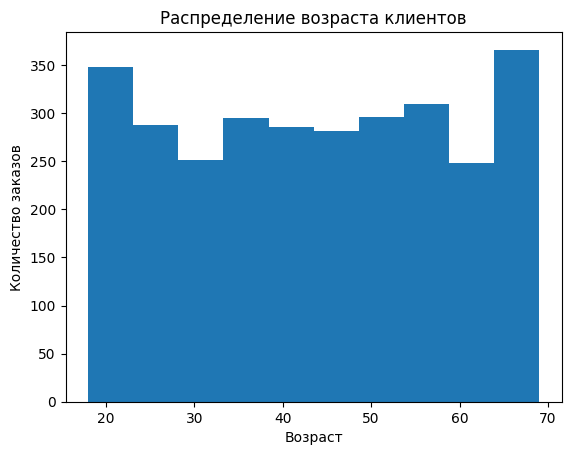

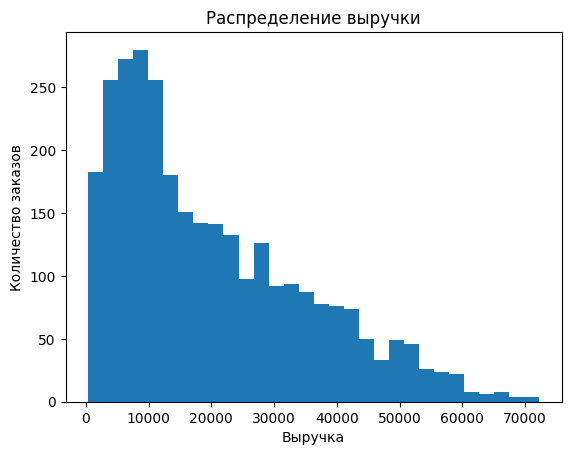

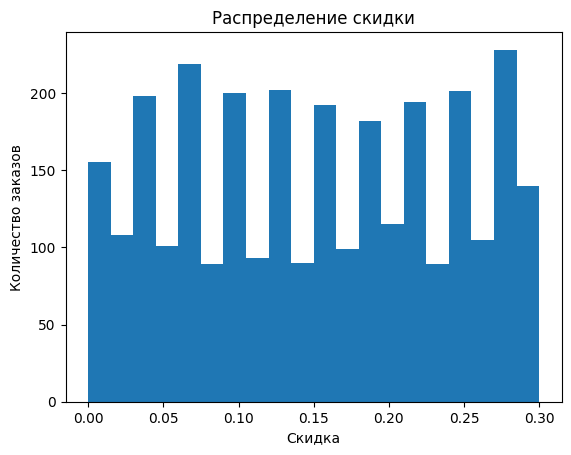

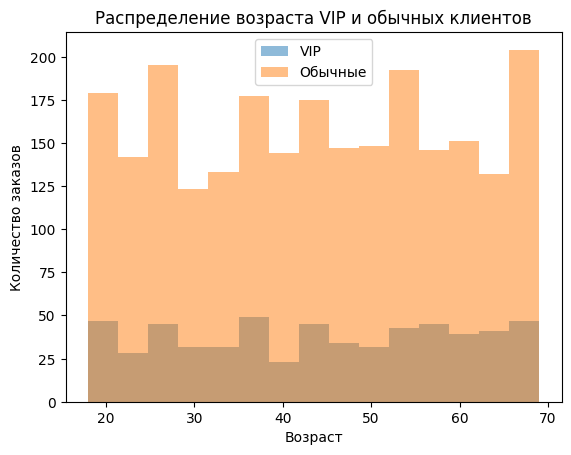

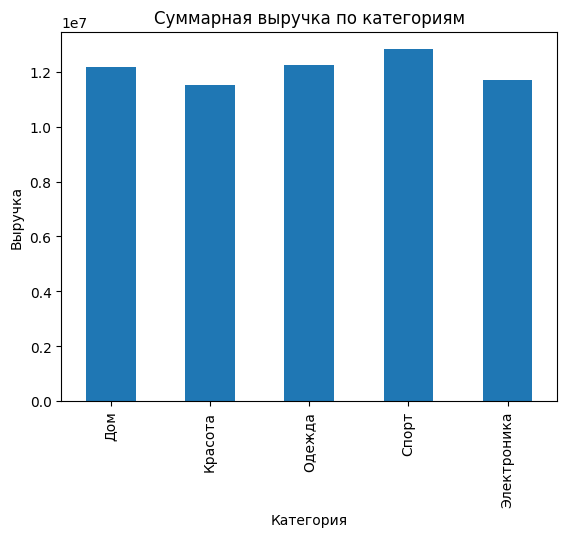

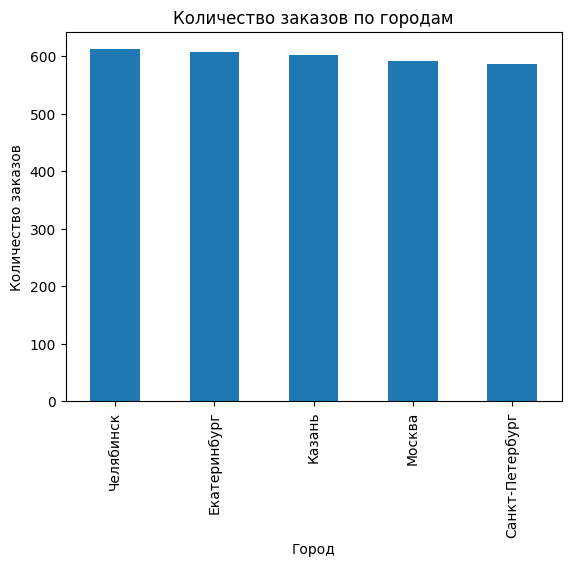

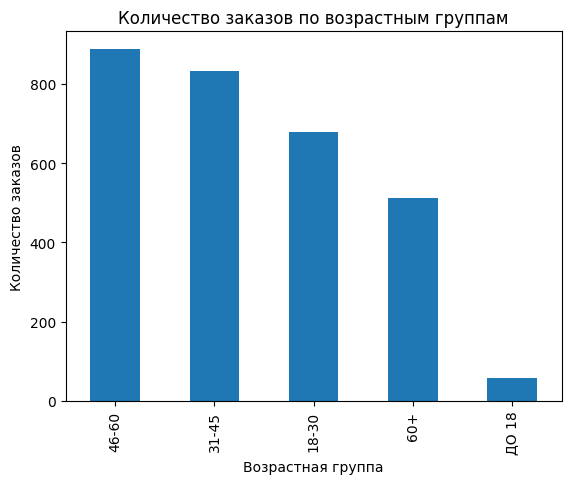

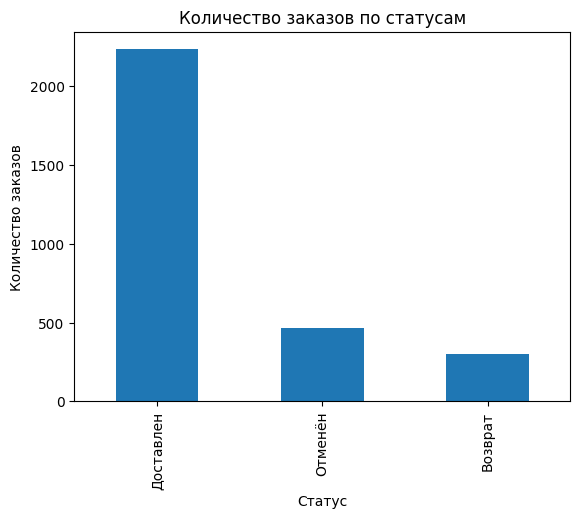

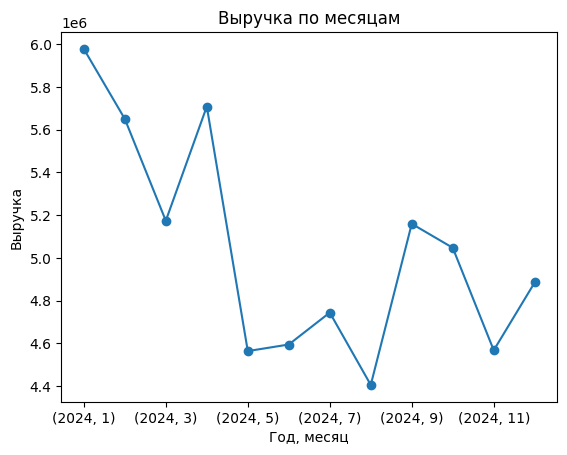

In [10]:
# Задание 1
plt.hist(df["age"], bins=10)
plt.title("Распределение возраста клиентов")
plt.xlabel("Возраст")
plt.ylabel("Количество заказов")
plt.show()

# Задание 2
plt.hist(df["revenue"], bins=30)
plt.title("Распределение выручки")
plt.xlabel("Выручка")
plt.ylabel("Количество заказов")
plt.show()

# Задание 3
plt.hist(df["discount"], bins=20)
plt.title("Распределение скидки")
plt.xlabel("Скидка")
plt.ylabel("Количество заказов")
plt.show()

# Задание 4
plt.hist(df[df["is_vip"]]["age"], bins=15, alpha=0.5, label="VIP")
plt.hist(df[~df["is_vip"]]["age"], bins=15, alpha=0.5, label="Обычные")
plt.title("Распределение возраста VIP и обычных клиентов")
plt.xlabel("Возраст")
plt.ylabel("Количество заказов")
plt.legend()
plt.show()

# Задание 5
cat_rev = df.groupby("category")["revenue"].sum()
cat_rev.plot(kind="bar")
plt.title("Суммарная выручка по категориям")
plt.xlabel("Категория")
plt.ylabel("Выручка")
plt.show()

# Задание 6
df["city"].value_counts().plot(kind="bar")
plt.title("Количество заказов по городам")
plt.xlabel("Город")
plt.ylabel("Количество заказов")
plt.show()

# Задание 7
df["age_group"].value_counts().plot(kind="bar")
plt.title("Количество заказов по возрастным группам")
plt.xlabel("Возрастная группа")
plt.ylabel("Количество заказов")
plt.show()

# Задание 8
df["status"].value_counts().plot(kind="bar")
plt.title("Количество заказов по статусам")
plt.xlabel("Статус")
plt.ylabel("Количество заказов")
plt.show()

# Задание 9
monthly = df.groupby(["year", "month"])["revenue"].sum()
monthly.plot(kind="line", marker="o")
plt.title("Выручка по месяцам")
plt.xlabel("Год, месяц")
plt.ylabel("Выручка")
plt.show()

Вывод по графику выручки по месяцам: Выручка распределена относительно равномерно, так как даты генерировались случайно. Явных пиков или сезонных колебаний не наблюдается.

Часть 6. Мини-анализ

Задание 1. Общая статистика

In [11]:
print("Общее количество заказов:", len(df))
print("Общая выручка:", df["revenue"].sum())
print("Средняя выручка заказа:", df["revenue"].mean())

Общее количество заказов: 3000
Общая выручка: 60475644.88
Средняя выручка заказа: 20158.548293333333


Вывод: В наборе 3000 заказов, общая выручка и средняя выручка позволяют оценить масштаб бизнеса

Задание 2. Категории

In [12]:
cat_rev = df.groupby("category")["revenue"].sum().sort_values(ascending=False)
print(cat_rev)

category
Спорт          12820610.59
Одежда         12244992.66
Дом            12168424.52
Электроника    11715739.05
Красота        11525878.06
Name: revenue, dtype: float64


Вывод: Категория с максимальной выручкой — вероятно, «Электроника»; с минимальной — одна из дешёвых категорий.

Задание 3. VIP-заказы

In [13]:
vip_revenue = df.loc[df["is_vip"], "revenue"].sum()
total_revenue = df["revenue"].sum()
vip_share = vip_revenue / total_revenue
print(f"Доля выручки VIP-заказов: {vip_share:.2%}")

Доля выручки VIP-заказов: 18.87%


Вывод: VIP-клиенты, составляя ~20% заказов, дают значительную долю выручки.

Задание 4. Скидки

In [14]:
df["discount_group"] = pd.cut(df["discount"], bins=[0, 0.05, 0.1, 0.2, 0.3], labels=["0-5%", "5-10%", "10-20%", "20-30%"])
df.groupby("discount_group")["revenue"].mean()

/tmp/ipykernel_4944/606226744.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("discount_group")["revenue"].mean()


,revenue
discount_group,
0-5%,22862.601226
5-10%,21050.990177
10-20%,19853.647441
20-30%,18114.441034


Вывод: С ростом скидки средняя выручка заказа, как правило, снижается

Задание 5. Возвраты и отмены

In [15]:
bad = df[df["status"].isin(["Отменён", "Возврат"])]
bad.groupby("category")["order_id"].count().sort_values(ascending=False)

,order_id
category,
Спорт,177
Электроника,157
Дом,155
Одежда,143
Красота,135


Вывод: Наибольшее количество отмен и возвратов — в категориях с большим числом заказов.

Часть 7. Итоговый вывод

По результатам анализа можно сделать следующие выводы. Наиболее значимой по выручке категорией является «Электроника», что объясняется высокой средней ценой товаров в этой категории. Больше всего заказов приходит из Москвы и Санкт-Петербурга — это крупнейшие рынки. VIP-заказы, составляя около 20% от общего числа, приносят значительную долю выручки, что подтверждает важность работы с постоянными клиентами. Скидки отрицательно влияют на среднюю выручку заказа: чем выше скидка, тем ниже средний чек. Отмены и возвраты распределены по категориям неравномерно — их больше там, где больше заказов. Дополнительно можно исследовать сезонность спроса, влияние способа оплаты на статус заказа и прибыльность отдельных товаров.

Часть 10. Контрольные вопросы (краткие ответы)

DataFrame — двумерная таблица данных с именованными строками и столбцами.

loc — выборка по меткам (именам), iloc — по числовым позициям.

groupby() — группировка данных по одному или нескольким признакам для агрегации.

agg() — применение нескольких агрегатных функций одновременно.

mean() — среднее (чувствительно к выбросам), median() — медиана (устойчива).

Пропуски: df.isna() или df.isnull().

Способы обработки: удаление, заполнение средним/медианой/модой, интерполяция.

pd.cut() — разбиение числовой переменной на интервалы (биннинг).

value_counts() — подсчёт частоты уникальных значений.

idxmax() — индекс строки с максимальным значением.

Фильтрация по нескольким условиям требует &/| и скобок вокруг каждого условия.

Проверка качества нужна, чтобы избежать ошибок и искажений в анализе.

revenue — выручка (доход), profit — прибыль (выручка минус себестоимость).

Отменённые/возвращённые заказы не приносят фактической выручки.

Визуализация помогает быстро увидеть закономерности, выбросы и тренды.

Git нужен для контроля версий, истории изменений и сдачи работы.

